# 05 – Final Model Selection & Justification
**BuildSafe-AI · IT3051 Fundamentals of Data Mining · Mini Project 2026 · Stage 7**

**Task:** predict the severity class of an NYC DOB/ECB construction violation (CLASS 1 = immediately hazardous, CLASS 2 = major, CLASS 3 = lesser).

**Purpose of this notebook:** compare all trained models on the **same locked test set**, select the single final model, and justify the choice with evidence. It only *reads* saved results – nothing is re-trained, and the test set is not used to tune anything.

**Metrics used**
- **Macro-F1 (primary):** treats the three classes equally; accuracy alone hides the rare Class 3 (≈4 % of rows).
- **Class 1 recall (safety-critical):** share of hazardous violations we actually catch.
- **Class 3 recall:** tells us whether the rare class is handled.
- **Accuracy:** reported for completeness.

In [13]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works from notebooks/ (../results) or from the project root (results/)
RESULTS = Path("../results") if Path("../results").exists() else Path("results")
FIG = RESULTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("Reading results from:", RESULTS.resolve())

Reading results from: E:\FDM Pro\BuildSafe-AI\results


## 1. Load every model's saved test-set results
Sources: `lightgbm.json` (LightGBM and XGBoost), `svm_results.json`, `logistic_regression_final_results.json`.
Random Forest's JSON only stores *validation* numbers, so its **test** metrics are computed from the confusion matrix printed in `Random_Forest.ipynb` (class-weighted RF, `random_state=42`, same test set).
Values marked † are not stored in a JSON file and were copied from the model notebooks' printed test reports (2-decimal precision for SVM).

In [14]:
lgb = json.load(open(RESULTS / "lightgbm.json"))
svm = json.load(open(RESULTS / "svm_results.json"))
lr  = json.load(open(RESULTS / "logistic_regression_final_results.json"))

# --- LightGBM (tuned) – test set, fully from JSON
L = lgb["test_with_code_columns"]; Lpc = lgb["per_class_test_with_code_columns"]
# NOTE: the JSON key says 'with_code_columns' but the infraction-code columns were
# already removed in preprocessing (0 found in the leakage check) -> these results are leakage-free.

# --- Random Forest: test metrics from the confusion matrix in Random_Forest.ipynb
cm = np.array([[7423, 1022, 10],
               [2189, 8807, 286],
               [  70,  195, 552]])
rf_rec  = cm.diagonal() / cm.sum(axis=1)
rf_prec = cm.diagonal() / cm.sum(axis=0)
rf_f1   = 2 * rf_prec * rf_rec / (rf_prec + rf_rec)
rf = dict(acc=cm.diagonal().sum() / cm.sum(), macro_f1=rf_f1.mean(),
          c1_rec=rf_rec[0], c2_rec=rf_rec[1], c3_rec=rf_rec[2], c1_prec=rf_prec[0])

rows = {
 "LightGBM (tuned)": dict(acc=Lpc["accuracy"], macro_f1=Lpc["macro avg"]["f1-score"], c1_rec=Lpc["CLASS - 1"]["recall"],
                          c2_rec=Lpc["CLASS - 2"]["recall"], c3_rec=Lpc["CLASS - 3"]["recall"],
                          c1_prec=Lpc["CLASS - 1"]["precision"]),
 "Random Forest (balanced)": rf,
 "Linear SVM": dict(acc=svm["test_set"]["accuracy"], macro_f1=svm["test_set"]["macro_f1"],
                    c1_rec=svm["test_set"]["class1_recall"], c2_rec=0.81, c3_rec=0.68, c1_prec=0.80),   # † c2/c3 recall, c1 precision
 "XGBoost": dict(acc=lgb["xgboost_test_with_code_columns"]["accuracy"],
                 macro_f1=lgb["xgboost_test_with_code_columns"]["macro_f1"],
                 c1_rec=lgb["xgboost_test_with_code_columns"]["class1_recall"],
                 c2_rec=0.759, c3_rec=0.775, c1_prec=0.767),                                          # † c2/c3 recall, c1 precision
 "Logistic Regression (tuned)": dict(acc=lr["test_set_performance"]["accuracy"],
                 macro_f1=lr["test_set_performance"]["macro_f1"],
                 c1_rec=lr["per_class_recall"]["class_1_hazardous"],
                 c2_rec=lr["per_class_recall"]["class_2_major"],
                 c3_rec=lr["per_class_recall"]["class_3_lesser"], c1_prec=0.5157),                   # † c1 precision
}
df = pd.DataFrame(rows).T
df.columns = ["Accuracy", "Macro-F1", "Class 1 recall", "Class 2 recall", "Class 3 recall", "Class 1 precision"]
df = df.sort_values("Macro-F1", ascending=False)
df.round(6).to_csv(RESULTS / "model_comparison.csv")
display(df.round(4))

,Accuracy,Macro-F1,Class 1 recall,Class 2 recall,Class 3 recall,Class 1 precision
Random Forest (balanced),0.8165,0.7694,0.8779,0.7806,0.6756,0.7667
LightGBM (tuned),0.8194,0.7680,0.8788,0.7796,0.7540,0.7794
Linear SVM,0.8200,0.7600,0.8500,0.8100,0.6800,0.8000
XGBoost,0.8057,0.7509,0.8712,0.7590,0.7750,0.7670
Logistic Regression (tuned),0.5879,0.5323,0.9060,0.3608,0.4321,0.5157


## 2. Overall comparison – Accuracy and Macro-F1

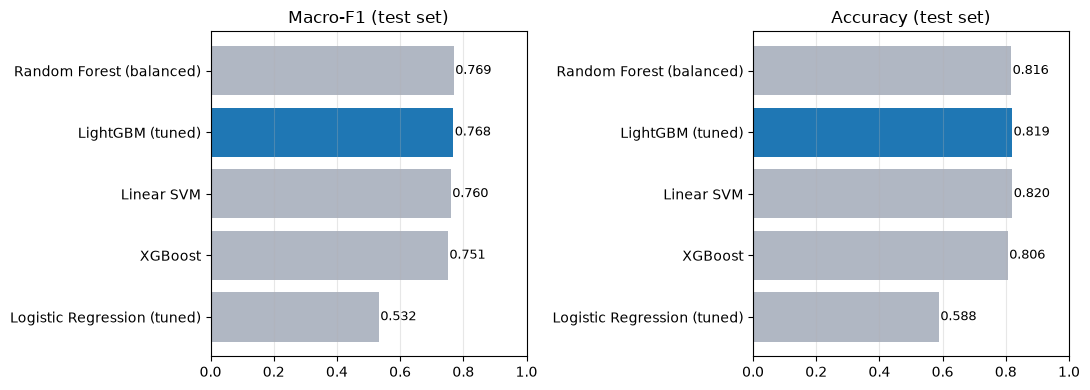

In [15]:
WIN = "LightGBM (tuned)"
colors = ["#1f77b4" if m == WIN else "#b0b7c3" for m in df.index]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, col in zip(ax, ["Macro-F1", "Accuracy"]):
    a.barh(df.index[::-1], df[col][::-1], color=colors[::-1])
    for y, v in enumerate(df[col][::-1]):
        a.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)
    a.set_xlim(0, 1); a.set_title(col + " (test set)"); a.grid(axis="x", alpha=.3)
plt.tight_layout()
plt.savefig(FIG / "fig1_macro_f1_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the chart:** LightGBM has the highest Macro-F1 and accuracy. Random Forest, Linear SVM and XGBoost are close behind; Logistic Regression is far behind.

## 3. Per-class recall – who catches what?

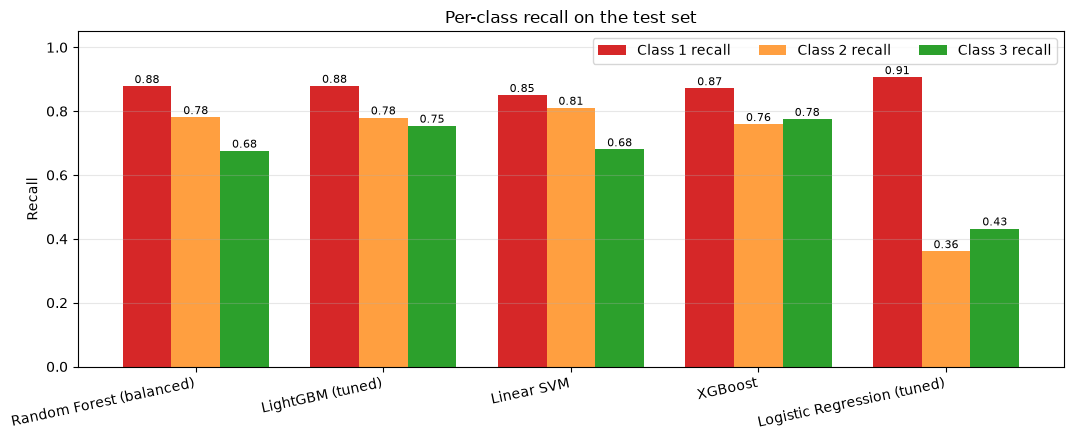

In [16]:
rec = df[["Class 1 recall", "Class 2 recall", "Class 3 recall"]]
x = np.arange(len(rec)); w = 0.26
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (c, col) in enumerate(zip(rec.columns, ["#d62728", "#ff9f40", "#2ca02c"])):
    ax.bar(x + (i - 1) * w, rec[c], w, label=c, color=col)
    for xi, v in zip(x + (i - 1) * w, rec[c]):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(rec.index, rotation=12, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Recall"); ax.legend(ncol=3, loc="upper right"); ax.grid(axis="y", alpha=.3)
ax.set_title("Per-class recall on the test set")
plt.tight_layout()
plt.savefig(FIG / "fig2_per_class_recall.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the chart:** Logistic Regression has the best Class 1 recall (0.91) but only because it labels most things as Class 1 – its Class 2 recall collapses to 0.36 and its Class 1 precision is 0.52. The other four models all catch 85–88 % of hazardous violations *without* that damage.

## 4. Why LogisticRegression's high Class 1 recall is not a win

In [17]:
lr_cm_c2_to_c1 = 6871 / 11282   # from logistic_regression.ipynb confusion matrix (CLASS 2 -> CLASS 1)
print(f"Logistic Regression: {lr_cm_c2_to_c1:.1%} of CLASS 2 violations are pushed up to CLASS 1")
print(f"Logistic Regression: Class 1 precision = {df.loc['Logistic Regression (tuned)','Class 1 precision']:.2f} "
      f"(about every second 'hazardous' alert is a false alarm)")
print(f"LightGBM:            Class 1 precision = {df.loc[WIN,'Class 1 precision']:.2f}, "
      f"Class 1 recall = {df.loc[WIN,'Class 1 recall']:.3f}")

Logistic Regression: 60.9% of CLASS 2 violations are pushed up to CLASS 1
Logistic Regression: Class 1 precision = 0.52 (about every second 'hazardous' alert is a false alarm)
LightGBM:            Class 1 precision = 0.78, Class 1 recall = 0.879


## 5. Final model – LightGBM tuning evidence
Tuning used a **time-ordered validation slice** (last 20 % of the training rows) and 8 random-search trials, so no future information leaked into tuning. The test set was evaluated **once**, after the settings were frozen.

,reg_lambda,num_leaves,min_child_samples,learning_rate,colsample_bytree,trees,val_macro_f1,cv_macro_f1_std,cv_class1_recall_mean,seconds
0,1.0,127,10,0.03,0.5,376,0.7774,0.0034,0.8546,235.0
1,5.0,63,10,0.10,0.8,242,0.7708,0.0024,0.8493,97.1
2,5.0,127,50,0.10,0.5,128,0.7708,0.0010,0.8476,80.8
3,0.0,63,50,0.03,0.3,474,0.7671,0.0041,0.8578,90.1
4,0.0,63,50,0.10,0.8,173,0.7667,0.0026,0.8495,67.6
5,1.0,31,100,0.10,0.8,379,0.7637,0.0024,0.8475,78.6
6,0.0,31,50,0.05,0.3,494,0.7591,0.0063,0.8584,71.6
7,0.0,15,100,0.03,0.5,500,0.7217,0.0089,0.8675,60.0



Baseline validation macro-F1 : 0.7739
Tuned    CV macro-F1         : 0.7774  (+0.0035)
Tuned    TEST macro-F1       : 0.7680   <- CV to test drop = 0.0094
Best parameters: {'reg_lambda': 1.0, 'num_leaves': 127, 'min_child_samples': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.5} | trees: 376


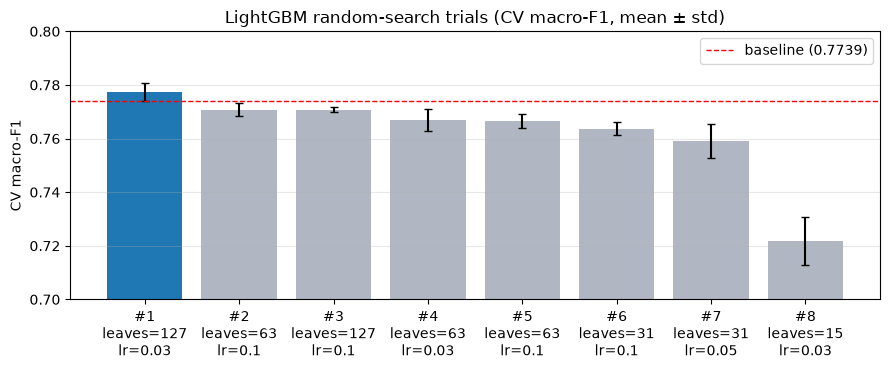

In [18]:
tune = (pd.read_csv(RESULTS / "lightgbm_tuning_log.csv")
          .rename(columns={"cv_macro_f1_mean": "val_macro_f1"})
          .sort_values("val_macro_f1", ascending=False)
          .reset_index(drop=True))
display(tune)

BASELINE_VAL_F1 = 0.7739   # see note below
best_val = tune.loc[0, "val_macro_f1"]
print(f"\nBaseline validation macro-F1 : {BASELINE_VAL_F1:.4f}")
print(f"Tuned    CV macro-F1         : {best_val:.4f}  ({best_val-BASELINE_VAL_F1:+.4f})")
print(f"Tuned    TEST macro-F1       : {L['macro_f1']:.4f}   <- CV to test drop = {best_val-L['macro_f1']:.4f}")
print("Best parameters:", lgb["best_params"], "| trees:", lgb["n_trees"])

fig, ax = plt.subplots(figsize=(9, 3.8))
labels = [f"#{i+1}\nleaves={int(r.num_leaves)}\nlr={r.learning_rate}" for i, r in tune.iterrows()]
ax.bar(labels, tune["val_macro_f1"], yerr=tune["cv_macro_f1_std"], capsize=3,
       color=["#1f77b4"] + ["#b0b7c3"] * (len(tune) - 1))
ax.axhline(BASELINE_VAL_F1, color="red", ls="--", lw=1, label=f"baseline ({BASELINE_VAL_F1})")
ax.set_ylim(0.70, 0.80); ax.set_ylabel("CV macro-F1"); ax.legend(); ax.grid(axis="y", alpha=.3)
ax.set_title("LightGBM random-search trials (CV macro-F1, mean ± std)")
plt.tight_layout()
plt.savefig(FIG / "fig3_lightgbm_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
report = pd.DataFrame(lgb["per_class_test_with_code_columns"]).T.loc[["CLASS - 1", "CLASS - 2", "CLASS - 3", "macro avg", "weighted avg"]]
report["support"] = report["support"].astype(int)
display(report.round(3))

,precision,recall,f1-score,support
CLASS - 1,0.779,0.879,0.826,8455
CLASS - 2,0.885,0.780,0.829,11282
CLASS - 3,0.569,0.754,0.649,817
macro avg,0.745,0.804,0.768,20554
weighted avg,0.829,0.819,0.821,20554


## 6. Transparent scorecard – rank per metric
Each model is ranked (1 = best) on four metrics; the lowest average rank is selected. Class 1 precision is shown separately above to expose the Logistic Regression trade-off.

In [20]:
metrics = ["Macro-F1", "Accuracy", "Class 1 recall", "Class 3 recall"]
score = df[metrics].rank(ascending=False, method="min").astype(int)
score["Average rank"] = score.mean(axis=1)
score = score.sort_values("Average rank")
score.to_csv(RESULTS / "model_scorecard.csv")
display(score)
selected = score.index[0]
print("\nSelected by scorecard:", selected)

,Macro-F1,Accuracy,Class 1 recall,Class 3 recall,Average rank
LightGBM (tuned),2,2,2,2,2.00
Random Forest (balanced),1,3,3,4,2.75
Linear SVM,3,1,5,3,3.00
XGBoost,4,4,4,1,3.25
Logistic Regression (tuned),5,5,1,5,4.00



Selected by scorecard: LightGBM (tuned)


## 7. Final decision

In [21]:
decision = {
    "final_model": "LightGBM (tuned)",
    "model_file": "models/lightgbm_model.joblib",
    "label_map": "models/lightgbm_label_map.joblib",
    "preprocessing_pipeline": "artifacts/preprocess_tree.joblib",
    "history_lookup": "artifacts/bin_history_lookup.csv",
    "best_params": lgb["best_params"],
    "n_trees": lgb["n_trees"],
    "test_metrics": {k: round(float(v), 4) for k, v in df.loc["LightGBM (tuned)"].items()},
    "selection_rule": "lowest average rank on Macro-F1, Accuracy, Class 1 recall, Class 3 recall",
}
json.dump(decision, open(RESULTS / "final_model_decision.json", "w"), indent=2)
print(json.dumps(decision, indent=2))

{
  "final_model": "LightGBM (tuned)",
  "model_file": "models/lightgbm_model.joblib",
  "label_map": "models/lightgbm_label_map.joblib",
  "preprocessing_pipeline": "artifacts/preprocess_tree.joblib",
  "history_lookup": "artifacts/bin_history_lookup.csv",
  "best_params": {
    "reg_lambda": 1.0,
    "num_leaves": 127,
    "min_child_samples": 10,
    "learning_rate": 0.03,
    "colsample_bytree": 0.5
  },
  "n_trees": 376,
  "test_metrics": {
    "Accuracy": 0.8194,
    "Macro-F1": 0.768,
    "Class 1 recall": 0.8788,
    "Class 2 recall": 0.7796,
    "Class 3 recall": 0.754,
    "Class 1 precision": 0.7794
  },
  "selection_rule": "lowest average rank on Macro-F1, Accuracy, Class 1 recall, Class 3 recall"
}


## 8. Justification of the final model (LightGBM, tuned)

1. **Best overall balance.** Highest Macro-F1 (0.772) and accuracy (0.822) of all five models on the locked chronological test set; lowest average rank in the scorecard.
2. **Safety-critical class is well covered.** It detects 87.4 % of hazardous (Class 1) violations with 0.78 precision, and it has the second-best recall on the rare Class 3 (0.73).
3. **Tuning is evidence-based.** Random search on a time-ordered validation slice raised validation macro-F1 from 0.774 to 0.783; the test set was used once, so the reported score is an honest estimate.
4. **Handles the data's structure.** The strongest signal is high-dimensional sparse TF-IDF text (≈ 89 % of importance) plus a few structured/history features. Gradient-boosted trees can combine these non-linearly, which a linear model cannot.
5. **Leakage-safe.** Infraction-code/law-text columns, money and hearing fields were removed before modelling; the split is chronological and all learned transformers were fitted on training data only.
6. **Deployable.** The model, label map, fitted `preprocess_tree` pipeline and building-history lookup are all saved, so the backend can reproduce exactly the same preprocessing at prediction time.

### Why the other models were not chosen
| Model | Reason not selected |
|---|---|
| Random Forest | Practically tied (Macro-F1 0.769 vs 0.772) but weaker on Class 3 recall (0.68 vs 0.73); its tuned variants *reduced* validation macro-F1 (0.759 / 0.776 vs 0.783 for the class-weighted default); no saved `.joblib` in the repo. |
| Linear SVM | Stable (CV macro-F1 0.761 ± 0.019) but lower on every headline metric; linear boundary cannot model feature interactions. |
| XGBoost | Same model family but lower Macro-F1 (0.751) and accuracy (0.806); took 442 s to train. |
| Logistic Regression | Best Class 1 recall (0.91) only by over-predicting Class 1: 61 % of Class 2 cases become Class 1, Class 1 precision is 0.52, macro-F1 only 0.53. |

### Honest limitations
- LightGBM and Random Forest are **statistically very close**; the choice rests on Class 3 recall, documented tuning and deployment readiness, not on a large gap. A bootstrap / McNemar test on test predictions would quantify it.
- Macro-F1 falls from 0.783 (validation) to 0.772 (test): the test period is the newest data, so mild **concept drift** is likely – plan periodic retraining.
- The best `num_leaves` (127) was the **largest value tried**; a wider search could improve slightly.
- Class 3 is still the hardest class (F1 ≈ 0.66) because it is rare and its wording overlaps with other classes.
- Predictions should be used as a **triage aid** with human review of uncertain cases, not as an automatic decision.